In [1]:
import os
from google.colab import userdata

os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")


In [2]:
!nvidia-smi

Wed Dec 10 14:36:02 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   66C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!pip install -q rfdetr==1.3.0 supervision==0.26.1 roboflow==1.2.10

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.3/266.3 kB 11.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.0/139.0 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.2/207.2 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.8/89.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 372.8/372.8 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
from roboflow import Roboflow
rf = Roboflow(api_key=os.environ["ROBOFLOW_API_KEY"] )
project = rf.workspace("roboflow-jvuqo").project("basketball-player-detection-3-ycjdo")
version = project.version(10)
dataset = version.download("coco", overwrite=True)




loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to basketball-player-detection-3-10 in coco:: 100%|██████████| 662/662 [00:00<00:00, 942.54it/s]


In [5]:
from rfdetr import RFDETRMedium

model = RFDETRMedium()

model.train(dataset_dir=dataset.location, epochs=30, batch_size=5, grad_accum_steps=4)

rf-detr-medium.pth: 100%|██████████| 386M/386M [00:04<00:00, 90.4MiB/s]


Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights
TensorBoard logging initialized. To monitor logs, use 'tensorboard --logdir output' and open http://localhost:6006/ in browser.
Not using distributed mode
git:
  sha: N/A, status: clean, branch: N/A

Namespace(num_classes=11, grad_accum_steps=4, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=5, weight_decay=0.0001, epochs=30, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-medium.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_l

Epoch: [0]  [ 0/23]  eta: 0:04:51  lr: 0.000100  class_error: 96.39  loss: 14.4505 (14.4505)  loss_ce: 1.3533 (1.3533)  loss_bbox: 0.4170 (0.4170)  loss_giou: 1.1178 (1.1178)  loss_ce_0: 1.2708 (1.2708)  loss_bbox_0: 0.4664 (0.4664)  loss_giou_0: 1.1572 (1.1572)  loss_ce_1: 1.3057 (1.3057)  loss_bbox_1: 0.4338 (0.4338)  loss_giou_1: 1.1609 (1.1609)  loss_ce_2: 1.3096 (1.3096)  loss_bbox_2: 0.4335 (0.4335)  loss_giou_2: 1.1193 (1.1193)  loss_ce_enc: 1.3147 (1.3147)  loss_bbox_enc: 0.4668 (0.4668)  loss_giou_enc: 1.1236 (1.1236)  loss_ce_unscaled: 1.3533 (1.3533)  class_error_unscaled: 96.3855 (96.3855)  loss_bbox_unscaled: 0.0834 (0.0834)  loss_giou_unscaled: 0.5589 (0.5589)  cardinality_error_unscaled: 3881.4001 (3881.4001)  loss_ce_0_unscaled: 1.2708 (1.2708)  loss_bbox_0_unscaled: 0.0933 (0.0933)  loss_giou_0_unscaled: 0.5786 (0.5786)  cardinality_error_0_unscaled: 3883.4001 (3883.4001)  loss_ce_1_unscaled: 1.3057 (1.3057)  loss_bbox_1_unscaled: 0.0868 (0.0868)  loss_giou_1_unscaled:

Test:  [ 0/20]  eta: 0:00:33  class_error: 13.13  loss: 7.2496 (7.2496)  loss_ce: 0.7578 (0.7578)  loss_bbox: 0.1147 (0.1147)  loss_giou: 0.5476 (0.5476)  loss_ce_0: 0.8242 (0.8242)  loss_bbox_0: 0.1167 (0.1167)  loss_giou_0: 0.5494 (0.5494)  loss_ce_1: 0.7617 (0.7617)  loss_bbox_1: 0.1140 (0.1140)  loss_giou_1: 0.5471 (0.5471)  loss_ce_2: 0.7578 (0.7578)  loss_bbox_2: 0.1110 (0.1110)  loss_giou_2: 0.5484 (0.5484)  loss_ce_enc: 0.8086 (0.8086)  loss_bbox_enc: 0.1233 (0.1233)  loss_giou_enc: 0.5672 (0.5672)  loss_ce_unscaled: 0.7578 (0.7578)  class_error_unscaled: 13.1313 (13.1313)  loss_bbox_unscaled: 0.0229 (0.0229)  loss_giou_unscaled: 0.2738 (0.2738)  cardinality_error_unscaled: 235.2000 (235.2000)  loss_ce_0_unscaled: 0.8242 (0.8242)  loss_bbox_0_unscaled: 0.0233 (0.0233)  loss_giou_0_unscaled: 0.2747 (0.2747)  cardinality_error_0_unscaled: 256.0000 (256.0000)  loss_ce_1_unscaled: 0.7617 (0.7617)  loss_bbox_1_unscaled: 0.0228 (0.0228)  loss_giou_1_unscaled: 0.2735 (0.2735)  cardina

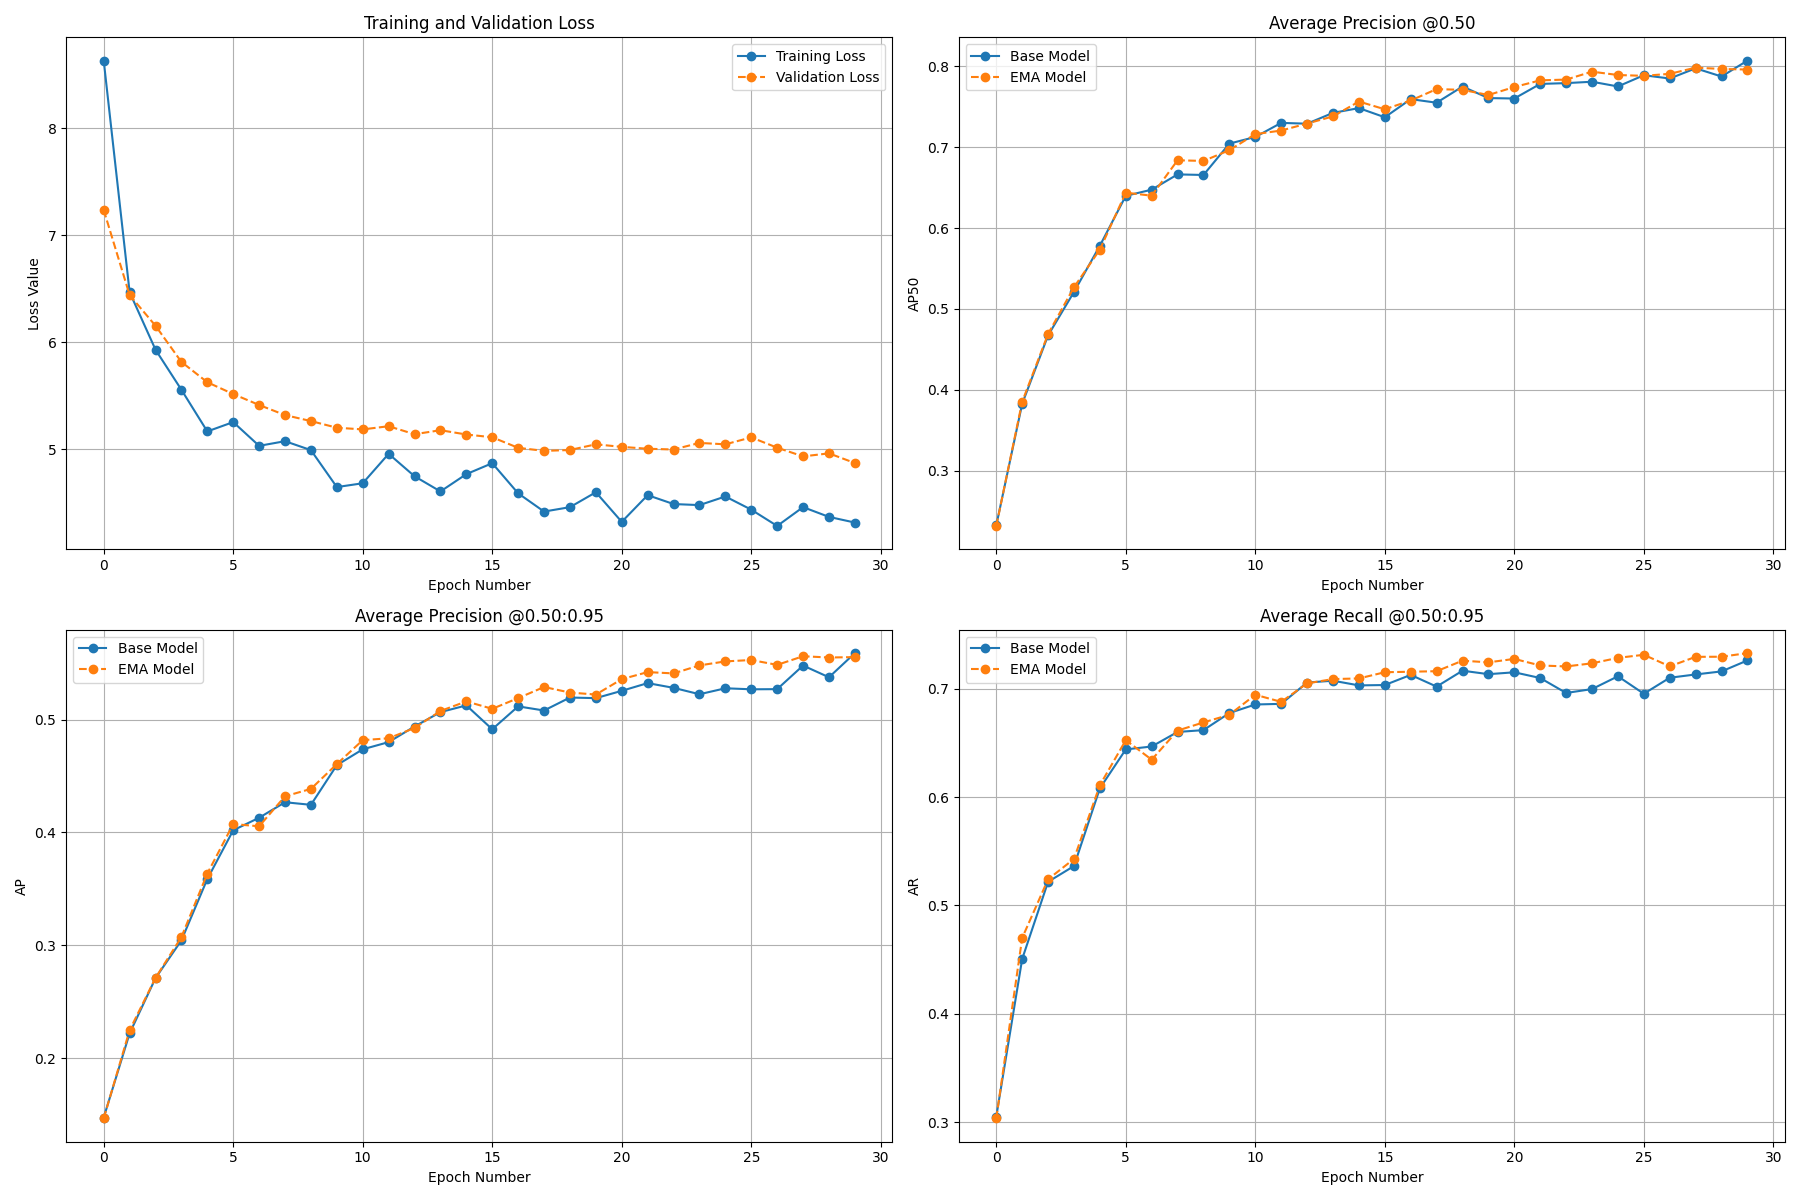

In [6]:
from PIL import Image

Image.open("/content/output/metrics_plot.png")

In [7]:


import gc
import torch
import weakref

def cleanup_gpu_memory(obj=None, verbose: bool = False):

    if not torch.cuda.is_available():
        if verbose:
            print("[INFO] CUDA is not available. No GPU cleanup needed.")
        return

    def get_memory_stats():
        allocated = torch.cuda.memory_allocated()
        reserved = torch.cuda.memory_reserved()
        return allocated, reserved

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[Before] Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

    # Ensure we drop all strong references
    if obj is not None:
        ref = weakref.ref(obj)
        del obj
        if ref() is not None and verbose:
            print("[WARNING] Object not fully garbage collected yet.")

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[After]  Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

In [8]:
cleanup_gpu_memory(model, verbose=True)

[Before] Allocated: 275.26 MB | Reserved: 13904.00 MB
[WARNING] Object not fully garbage collected yet.
[After]  Allocated: 275.26 MB | Reserved: 488.00 MB


In [9]:
model = RFDETRMedium(pretrain_weights="/content/output/checkpoint_best_total.pth")


Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


In [10]:
import supervision as sv

ds_test = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/test",
    annotations_path=f"{dataset.location}/test/_annotations.coco.json"
)

In [11]:
import supervision as sv
from tqdm import tqdm
from supervision.metrics import MeanAveragePrecision

targets = []
predictions = []

for path, image, annotations in tqdm(ds_test):
    image = Image.open(path)
    detections = model.predict(image, threshold=0)

    targets.append(annotations)
    predictions.append(detections)

100%|██████████| 94/94 [00:09<00:00,  9.49it/s]


In [12]:
map_metric = MeanAveragePrecision()
map_result = map_metric.update(predictions, targets).compute()
print(map_result)

Average Precision (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.557
Average Precision (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.790
Average Precision (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.619
Average Precision (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.432
Average Precision (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ]                 = 0.437
Average Precision (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ]                 = 0.654
